In [1]:
import warnings
warnings.simplefilter("ignore")

# load data
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
import statsmodels.formula.api as smf
from scipy.special import expit, logit

In [2]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from 
    :return df: <pandas DataFrame> 
    """
    coef = results.params
    std_err = results.bse
    
    df = pd.DataFrame(data = np.transpose([coef, std_err]), 
                      index = coef.index, 
                      columns=["coef","std err"])
    return df

# **Case 1 - Customer Churn Prediction**
---

Given the data containing information on 20,000 telecom customers.

We want to predicting whether a customer will **churn** (stop subscribing to the service), on the basis of how many times the customer has contacted **customer support**.

In [16]:
# load data
churn = pd.read_csv('customer_churn_dataset.csv')
churn

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No


Dataset describtion:

- customer_id: Unique identifier for each customer
- tenure: Number of months the customer has been subscribed to the service
- monthly_charges: Amount billed to the customer each month
- total_charges: Total amount billed to the customer over their tenure
- contract: Contract type (Month-to-month, One year, Two year)
- payment_method: How the customer pays their bill (Credit, Debit, Cash, UPI)
- internet_service: Type of internet service subscribed (DSL, Fiber, or none)
- tech_support: Whether the customer subscribes to tech support (No/Yes)
- online_security: Whether the customer subscribes to online security (No/Yes)
- support_calls: Number of times the customer contacted customer support
- churn: A factor with levels No and Yes indicating whether the customer churned

In [20]:
churn.groupby('churn')[['support_calls','monthly_charges','tenure','total_charges']].mean()

,support_calls,monthly_charges,tenure,total_charges
churn,,,,
No,1.337311,64.911829,37.780269,2454.145264
Yes,1.849481,79.813779,33.943300,2716.702461


Visualize churn and support_calls

<Axes: xlabel='support_calls', ylabel='churn'>

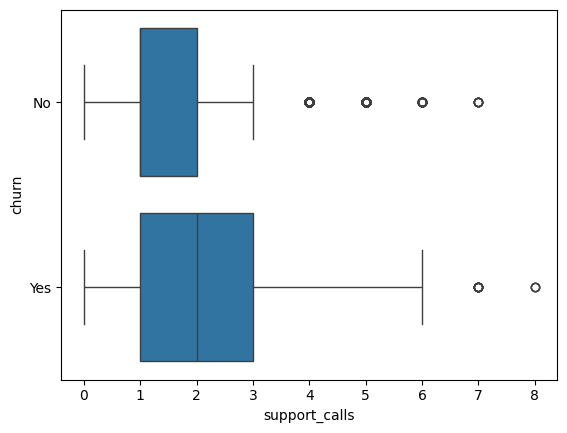

In [4]:
sns.boxplot(y = 'churn', x = 'support_calls', data = churn)

- The figure shows the distribution of support_calls split by the binary churn variable
- It appears that customers who churned tended to contact customer support more often than those who stayed

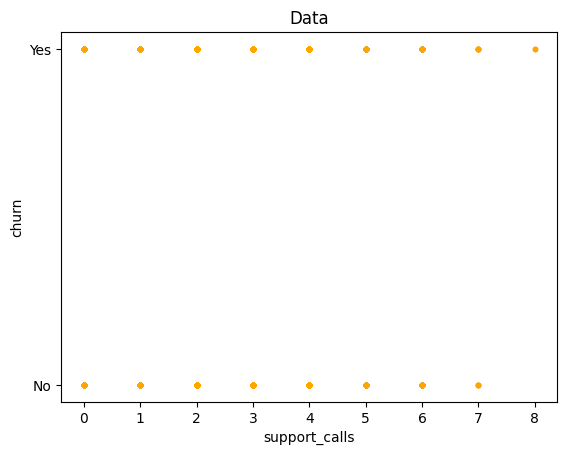

In [5]:
x = churn["support_calls"]
y = churn["churn"]

# Plot the data
plt.scatter(x, y, color = "orange", marker=".")

# Add a legend and labels

plt.xlabel("support_calls")
plt.ylabel("churn")

# Add a title and adjust the margins
plt.title("Data")

# Show the plot
plt.show()

### Data Preparation

Use LabelEncoder to convert the churn variable into numeric

In [6]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder Object and transform the churn variable
churn["churn"] = LabelEncoder().fit_transform(churn["churn"])

# Display the 5th first row after transforming
churn[["churn","support_calls"]].head()

,churn,support_calls
0,0,1
1,0,2
2,0,0
3,0,0
4,1,4


In [7]:
churn.isna().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

Note that `internet_service` has some missing values, but since we are only modelling churn using `support_calls`, this does not affect our model below.

### Fit Logistic Regression - Using Support Calls Variable

- Build the model using logit

In [8]:
# Create Logit model object
logit_model = smf.logit("churn ~ support_calls", churn)

# Fit the model
model_churn = logit_model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_churn_coef = print_coef_std_err(model_churn)

Optimization terminated successfully.
         Current function value: 0.623308
         Iterations 5


### Visualize the data and the logistic regression line

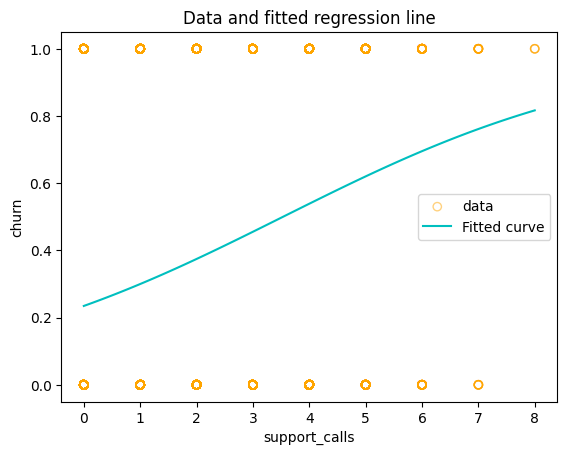

In [9]:
predictor = "support_calls"
outcome = "churn"
data = churn.copy()
results_ = results_churn_coef.copy()

# Plot the data
plt.scatter(data[predictor], data[outcome], marker= 'o', facecolors = "none", edgecolor="orange", alpha=0.5, label='data')

# Calculate the fitted values
a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

# get values from predictor range
x_range = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 100)

# predicted probabilities of x in x_range
pred_prob = expit(a_hat + b_hat*x_range)

# Plot the fitted line
plt.plot(x_range, pred_prob, label="Fitted curve", color = "c")

# Add a legend and labels
plt.legend()
plt.ylabel("churn")
plt.xlabel("support_calls")

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

### Coefficient Interpretation

In [10]:
results_churn_coef

,coef,std err
Intercept,-1.182326,0.025229
support_calls,0.334534,0.012327


$$P(\text{Churn}) = \text{logit}^{-1}(-1.182 + 0.335 \cdot \text{support\_calls})$$

- Positive coefficient indicates that customers who contact support more often tend to have a higher probability of churning
- To be precise, a one-unit increase in the number of support calls is associated with a positive difference in the log odds of churn by 0.335 units
- Using divide by 4 rule: near the average number of support calls,
  - 1 additional support call corresponds to an approximately 8.4% (0.335/4) increase in the probability of churn

### Prediction

- Next, make a prediction of churn probability for two customers with a difference of 4 support calls (1 call vs 5 calls)

In [11]:
new_calls = np.array([1,5])
new_data = pd.DataFrame(data = new_calls, columns = ["support_calls"])

In [12]:
new_data["predicted_p_churn"] = model_churn.predict(new_data)
new_data

,support_calls,predicted_p_churn
0,1,0.299896
1,5,0.620187


- The model predicts that a customer who has only contacted support once has about a 30% probability of churning
- In contrast, a customer who has contacted support 5 times has a much higher predicted churn probability, equal to 0.620 or 62.0 %